# Lista 8

## Imports

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay


## Zadanie 1

In [7]:
X, y = make_classification(n_samples=1000, n_features=10)

In [98]:
def generate_credit_data(n_samples=1000, n_features=10, random_state=42):
    """Generuje syntetyczne dane kredytowe."""
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=6,
        n_redundant=2,
        n_clusters_per_class=2,
        random_state=random_state,
    )
    return X, y


def bootstrap_sample(X, y, random_state=None):
    """Losuje próbkę bootstrap (n próbek ze zwracaniem z n). """
    rng = np.random.RandomState(random_state)
    n = len(X)
    indices = rng.choice(n, size=n, replace=True)
    oob_indices = list(set(range(n)) - set(indices))
    return X[indices], y[indices], oob_indices


def train_single_trees(X_train, y_train, n_trees=10):
    """Trenuje n pojedynczych drzew z różnymi seedami."""
    trees = []
    for seed in range(n_trees):
        tree = DecisionTreeClassifier(random_state=seed)
        tree.fit(X_train, y_train)
        trees.append(tree)
    return trees


def calculate_prediction_variance(trees, X):
    """Oblicza wariancję predykcji między drzewami.

    TODO:
    - Zbierz `predict_proba` ze wszystkich drzew
    - Oblicz wariancję dla każdego punktu
    """
    all_probabilities = np.stack([tree.predict_proba(X) for tree in trees])
    return np.var(all_probabilities, axis=0)[:, 0]

def ensemble_predict(trees, X):
    """Agreguje predykcje wielu drzew przez głosowanie większościowe.

    TODO:
    - Zbierz predykcje ze wszystkich drzew
    - Dla każdego punktu zwróć najczęściej występującą klasę
    """
    all_preds = np.stack([tree.predict(X) for tree in trees])
    most_common = [Counter(all_preds[:, i]).most_common(1)[0][0] for i in range(len(all_preds))]
    return most_common



def calculate_oob_error(X, y, trees, oob_indices_list):
    """Oblicza OOB error bez zbioru walidacyjnego.

    `oob_indices_list` musi być listą OOB indeksów równoległą do `trees`.

    TODO:
    - Dla każdego punktu użyj tylko drzew, które go nie widziały
    - Zagłosuj i porównaj z prawdziwą etykietą
    """
    correct = 0
    counted = 0
    for i in range(len(X)):
        oob_trees = trees[[j for j in range(len(trees)) if i in oob_indices_list[j]]]
        if len(oob_trees) == 0:
            continue
        oob_preds = [tree.predict(X[i]) for tree in oob_trees]
        vote_pred = Counter(oob_preds).most_common(1)[0][0]
        correct += int(vote_pred == y[i])
        counted += 1
    return 1 - (correct / counted)




### Podpunkt a

In [99]:
X, y = generate_credit_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
trees = train_single_trees(X_train, y_train)

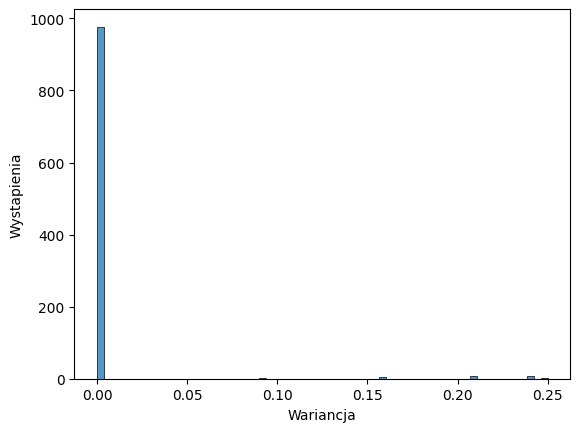

Liczba punktow z wysoka wariancja: 23


In [111]:
variances = calculate_prediction_variance(trees, X)
sns.histplot(variances)
plt.xlabel('Wariancja')
plt.ylabel('Wystapienia')
plt.show()
print('Liczba punktow z wysoka niestabilnoscia:', np.sum(variances > 0.05))

In [ ]:
np.meshgrid()

DecisionBoundaryDisplay()